In [1]:
from zipfile import ZipFile
dataset = '/content/dementia.zip'
with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [2]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

In [3]:
data_dir = '/content/dementia'

In [4]:
image_height, image_width = 128, 128

In [5]:
preprocessed_images = []
labels = []

In [8]:
# Iterate through the data directory
for folder in os.listdir(data_dir):
    if folder == 'NonDemented':
        label = 0
    elif folder == 'MildDemented':
        label = 1
    elif folder == 'VeryMildDemented':
        label = 2
    elif folder == 'ModerateDemented':
        label = 3
    else:
        continue

    folder_path = os.path.join(data_dir, folder)

    # Iterate through images in the folder
    for file in os.listdir(folder_path):
        if file.endswith('.jpg'):
            image_path = os.path.join(folder_path, file)

            # Read and resize the image
            image = cv2.imread(image_path)
            image = cv2.resize(image, (image_height, image_width))

            # Normalize the pixel values
            image = image / 255.0

            # Append the preprocessed image and its label
            preprocessed_images.append(image)
            labels.append(label)

In [9]:
# Convert lists to numpy arrays
preprocessed_images = np.array(preprocessed_images)
labels = np.array(labels)

In [10]:
# Shuffle the data
shuffle_indices = np.random.permutation(preprocessed_images.shape[0])
preprocessed_images = preprocessed_images[shuffle_indices]
labels = labels[shuffle_indices]

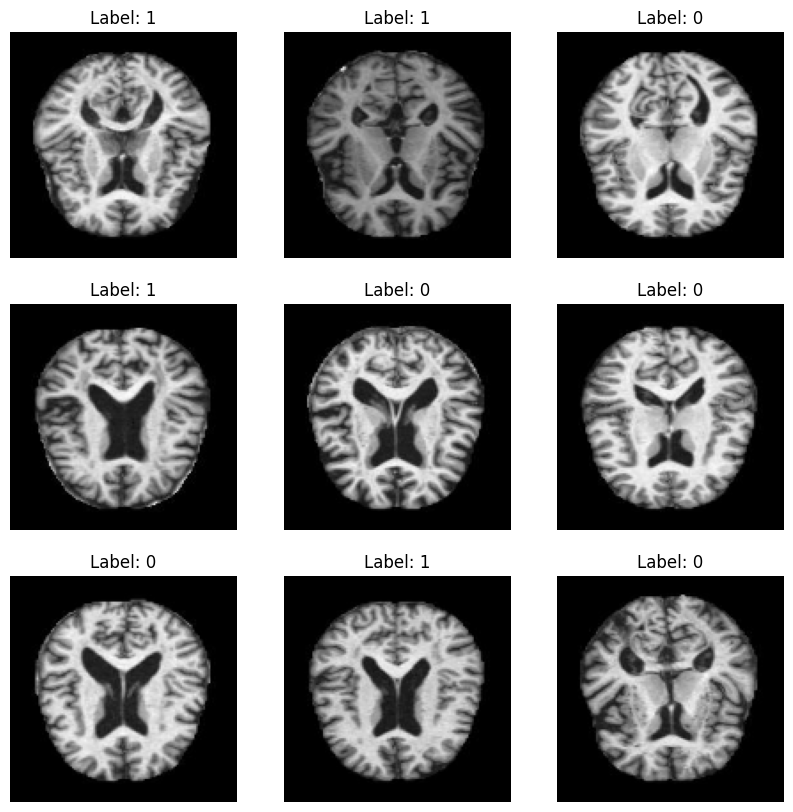

In [11]:
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    rand_index = random.randint(0, len(preprocessed_images))
    plt.imshow(preprocessed_images[rand_index])
    plt.title(f"Label: {labels[rand_index]}")
    plt.axis("off")
plt.show()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(preprocessed_images, labels, test_size=0.2, random_state=42)

In [16]:
# Define the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(image_height, image_width, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(4, activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
83/83 [==============================] - 96s 1s/step - loss: 0.6780 - accuracy: 0.7054 - val_loss: 0.5533 - val_accuracy: 0.7557
Epoch 2/10
83/83 [==============================] - 91s 1s/step - loss: 0.4924 - accuracy: 0.7931 - val_loss: 0.3868 - val_accuracy: 0.8416
Epoch 3/10
83/83 [==============================] - 85s 1s/step - loss: 0.3035 - accuracy: 0.8780 - val_loss: 0.2559 - val_accuracy: 0.9140
Epoch 4/10
83/83 [==============================] - 88s 1s/step - loss: 0.1424 - accuracy: 0.9460 - val_loss: 0.1830 - val_accuracy: 0.9397
Epoch 5/10
83/83 [==============================] - 88s 1s/step - loss: 0.0717 - accuracy: 0.9762 - val_loss: 0.1619 - val_accuracy: 0.9397
Epoch 6/10
83/83 [==============================] - 86s 1s/step - loss: 0.0372 - accuracy: 0.9879 - val_loss: 0.0900 - val_accuracy: 0.9774
Epoch 7/10
83/83 [==============================] - 85s 1s/step - loss: 0.0245 - accuracy: 0.9928 - val_loss: 0.0653 - val_accuracy: 0.9804
Epoch 8/10
83/83 [==

In [17]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
160/160 [==============================] - 154s 952ms/step - loss: 0.9992 - accuracy: 0.5158 - val_loss: 0.8584 - val_accuracy: 0.6227
Epoch 2/10
160/160 [==============================] - 146s 916ms/step - loss: 0.7977 - accuracy: 0.6453 - val_loss: 0.7693 - val_accuracy: 0.6273
Epoch 3/10
160/160 [==============================] - 150s 937ms/step - loss: 0.5343 - accuracy: 0.7711 - val_loss: 0.4782 - val_accuracy: 0.8047
Epoch 4/10
160/160 [==============================] - 149s 931ms/step - loss: 0.2574 - accuracy: 0.9006 - val_loss: 0.2917 - val_accuracy: 0.8844
Epoch 5/10
160/160 [==============================] - 149s 930ms/step - loss: 0.1177 - accuracy: 0.9621 - val_loss: 0.2114 - val_accuracy: 0.9383
Epoch 6/10
160/160 [==============================] - 150s 936ms/step - loss: 0.0464 - accuracy: 0.9846 - val_loss: 0.2614 - val_accuracy: 0.8992
Epoch 7/10
160/160 [==============================] - 164s 1s/step - loss: 0.0136 - accuracy: 0.9967 - val_loss: 0.1060 - va

In [18]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc}')

21/21 [==============================] - 8s 351ms/step - loss: 0.0653 - accuracy: 0.9834
Test accuracy: 0.9834087491035461


In [19]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
model.save('/content/drive/My Drive/final_year_project/model.h5')
